## Task 3. 
A use case exploration.
Nord Pool consists of the commercial power exchange function, Nord Pool, and the 
Market Coupling Operator function, Nord Pool European Market Coupling Operator. Nord 
Pool is Europe's leading power market and offers trading, clearing, settlement and 
associated services in both day-ahead and intraday markets across 16 European 
countries. Their product includes power price produced within their markets every hour, 
every day
(https://www.nordpoolgroup.com/en/Aboutus/#:~:text=Nord%20Pool%20is%20Europe's%20leading,markets%20every%20hour%2C
%20every%20day).
3.1 Look into the webpage, choose several cities in Norway and several other European 
countries, and then download weekly data in October 2022: 
https://www.nordpoolgroup.com/en/Market-data1/Dayahead/Area-Prices/
3.2 Look into the same webpage, choose a day in November 2022 and download the 
hourly data from the several countries and cities mentioned above
3.3 Write python code to properly load these data, use any relevant data handling 
methods (for example, data transformation, missing data handling, filling NaN 
values and so on) to convert the data to Series, DataFrames. Then perform analysis 
and visualization to compare the price changes between different countries in EU 
and different cities in Norway.

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [24]:
# 3.3
# import the downloaded data into python as df_prices_%
df_prices_october = pd.read_csv('weekly_prices_october_2022.csv')
# checking if there are NaN values and checking the data types
df_prices_october.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Week          6 non-null      int64  
 1   Oslo          6 non-null      float64
 2   Kristiansand  6 non-null      float64
 3   Bergen        6 non-null      float64
 4   Molde         6 non-null      float64
 5   Trondheim     6 non-null      float64
 6   Tromso        6 non-null      float64
 7   GER           6 non-null      float64
 8   AT            6 non-null      float64
 9   FR            6 non-null      float64
 10  NL            6 non-null      float64
 11  PL            6 non-null      float64
 12  FI            6 non-null      float64
dtypes: float64(12), int64(1)
memory usage: 756.0 bytes


In [25]:
# 3.3
df_prices_november = pd.read_csv('hourly_prices_2022_11_23.csv')
df_prices_november.info()
# there is no other data cleaning necessary because the columns have no null values, and also there are no other reasons to change something in the dataframe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Hour          24 non-null     int64  
 1   Oslo          24 non-null     float64
 2   Kristiansand  24 non-null     float64
 3   Bergen        24 non-null     float64
 4   Trondheim     24 non-null     float64
 5   Molde         24 non-null     float64
 6   Tromso        24 non-null     float64
 7   GER           24 non-null     float64
 8   AT            24 non-null     float64
 9   FR            24 non-null     float64
 10  NL            24 non-null     float64
 11  PL            24 non-null     float64
 12  FI            24 non-null     float64
dtypes: float64(12), int64(1)
memory usage: 2.6 KB


In [26]:
# 3.3 - An overview of the data including the cities and countries and different statistical measures
df_prices_october.describe()

,Week,Oslo,Kristiansand,Bergen,Molde,Trondheim,Tromso,GER,AT,FR,NL,PL,FI
count,6.000000,6.00000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000,6.000000
mean,41.500000,136.87500,137.168333,136.906667,36.695000,36.695000,20.653333,166.981667,192.033333,193.913333,168.360000,139.711667,126.778333
std,1.870829,62.01441,62.169334,62.079680,16.094287,16.094287,5.886257,62.364773,65.517105,77.495913,65.810956,18.360259,61.629062
min,39.000000,73.53000,73.710000,73.530000,15.910000,15.910000,14.570000,107.280000,122.080000,107.740000,101.410000,122.060000,69.800000
25%,40.250000,95.93000,95.992500,95.930000,26.510000,26.510000,18.407500,118.222500,146.522500,134.522500,118.062500,125.482500,87.732500
50%,41.500000,122.16500,121.945000,122.165000,36.335000,36.335000,19.350000,154.220000,181.285000,186.605000,157.215000,137.585000,115.915000
75%,42.750000,160.16750,161.510000,160.167500,44.517500,44.517500,20.330000,197.890000,219.152500,240.112500,200.230000,145.937500,133.410000
max,44.000000,243.37000,243.370000,243.560000,61.110000,61.110000,31.900000,267.500000,300.840000,307.420000,274.740000,170.870000,241.460000


In [27]:
# Creating NOR (mean of Norway) in the data for countries
df_prices_october['NOR'] = df_prices_october[['Oslo', 'Kristiansand', 'Bergen', 'Molde', 'Tromso', 'Trondheim']].mean(axis=1).round(3)
df_prices_october

,Week,Oslo,Kristiansand,Bergen,Molde,Trondheim,Tromso,GER,AT,FR,NL,PL,FI,NOR
0,39,243.37,243.37,243.56,61.11,61.11,31.90,267.50,300.84,307.42,274.74,170.87,241.46,147.403
1,40,93.00,93.23,93.00,24.83,24.83,19.97,159.37,203.41,245.38,178.84,122.06,79.97,58.143
2,41,167.02,168.81,167.02,15.91,15.91,14.57,210.73,224.40,224.31,207.36,146.45,69.80,91.540
3,42,139.61,139.61,139.61,45.65,45.65,18.73,149.07,159.16,148.90,135.59,144.40,137.61,88.143
4,43,104.72,104.28,104.72,41.12,41.12,20.45,107.94,122.08,107.74,101.41,130.77,120.81,69.402
5,44,73.53,73.71,73.53,31.55,31.55,18.30,107.28,142.31,129.73,112.22,123.72,111.02,50.362


Graphic 1:


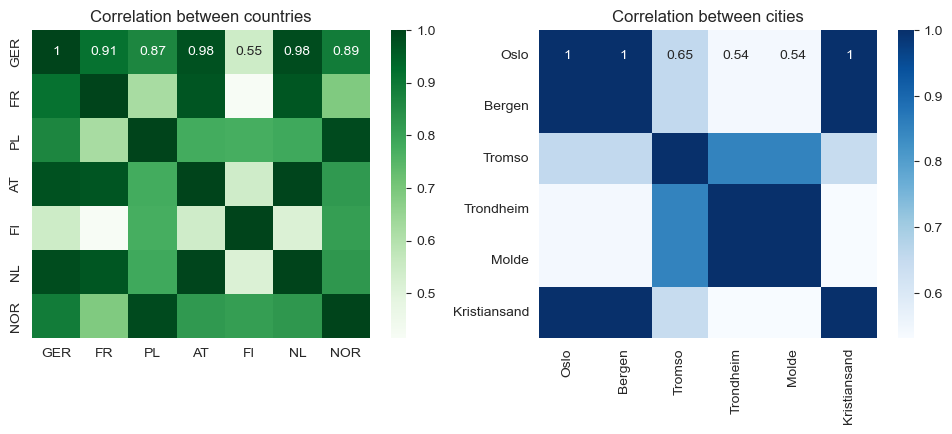

In [28]:
# Initiating two subplots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,4))

# correlation countries (October)
corr_col_countries = df_prices_october[['GER', 'FR', 'PL', 'AT', 'FI', 'NL', 'NOR']]
corr_col_countries = corr_col_countries.corr()
sns.heatmap(corr_col_countries, annot=True, cmap='Greens', ax=axes[0])
axes[0].set_title('Correlation between countries')

# correlation cities (October)
corr_col_cities = df_prices_october[['Oslo', 'Bergen', 'Tromso', 'Trondheim', 'Molde', 'Kristiansand']]
corr_col_cities = corr_col_cities.corr()
sns.heatmap(corr_col_cities, annot=True, cmap='Blues', ax=axes[1])
axes[1].set_title('Correlation between cities')

print('Graphic 1:')
plt.show()

C:\Users\amund\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\amund\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\amund\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\amund\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_cat

Graphic 2:


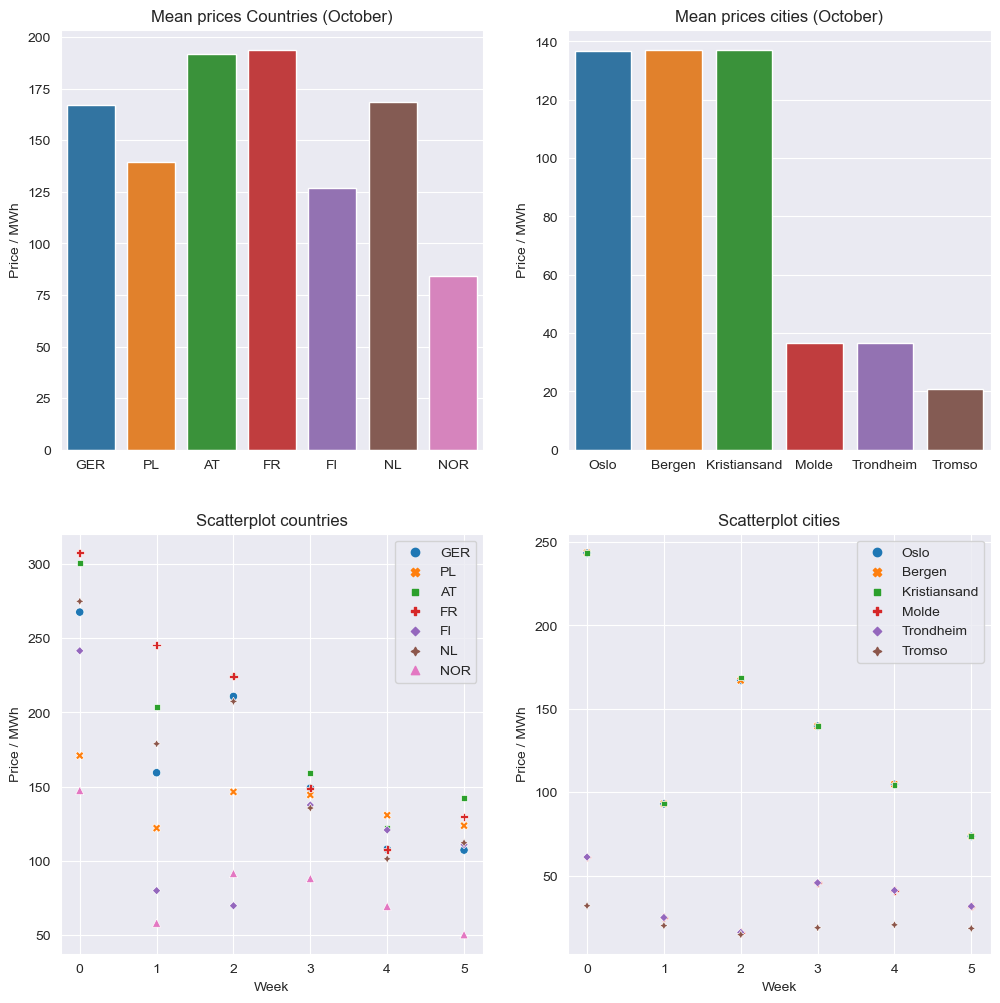

In [29]:
# Creating the data for the barplot and scatterplot
barplot_values_countries = df_prices_october[['GER', 'PL', 'AT', 'FR', 'FI', 'NL', 'NOR']]
barplot_values_cities = df_prices_october[['Oslo', 'Bergen', 'Kristiansand', 'Molde', 'Trondheim', 'Tromso']]
scat_values_countries = df_prices_october[['GER', 'PL', 'AT', 'FR', 'FI', 'NL', 'NOR']]
scat_values_cities = df_prices_october[['Oslo', 'Bergen', 'Kristiansand', 'Molde', 'Trondheim', 'Tromso']]

# country barplot
fig, axes = plt.subplots(nrows=2, ncols=2, figsize= (12,12))
sns.barplot(x=barplot_values_countries.columns, 
            y= barplot_values_countries.mean(), ax=axes[0,0])
axes[0,0].set_title('Mean prices Countries (October)')
axes[0,0].set_ylabel('Price / MWh')

# city barplot
sns.barplot(x=barplot_values_cities.columns, 
            y=barplot_values_cities.mean(),
            ax=axes[0,1])
axes[0,1].set_title('Mean prices cities (October)')
axes[0,1].set_ylabel('Price / MWh')

# scatterplot Countries
sns.scatterplot(scat_values_countries, ax=axes[1,0])
axes[1,0].set_title('Scatterplot countries')
axes[1,0].set_xlabel('Week')
axes[1,0].set_ylabel('Price / MWh')

# scatterplot cities
sns.scatterplot(scat_values_cities, ax=axes[1,1])
axes[1,1].set_title('Scatterplot cities')
axes[1,1].set_xlabel('Week')
axes[1,1].set_ylabel('Price / MWh')

print('Graphic 2:')
plt.show()

In [30]:
# Creating two new dataframes for cities and countries on november 29.
df_prices_november['NOR'] = df_prices_november[['Oslo', 'Kristiansand', 'Bergen', 'Molde', 'Tromso', 'Trondheim']].mean(axis=1)
df_prices_november_cities = df_prices_november[['Hour','Oslo', 'Bergen', 'Kristiansand', 'Tromso', 'Trondheim', 'Molde']]
df_prices_november_countries = df_prices_november[['Hour', 'GER', 'FR', 'PL', 'FI', 'AT', 'NL', 'NOR']]

C:\Users\amund\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\amund\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\amund\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\amund\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_cat

Graphic 3:


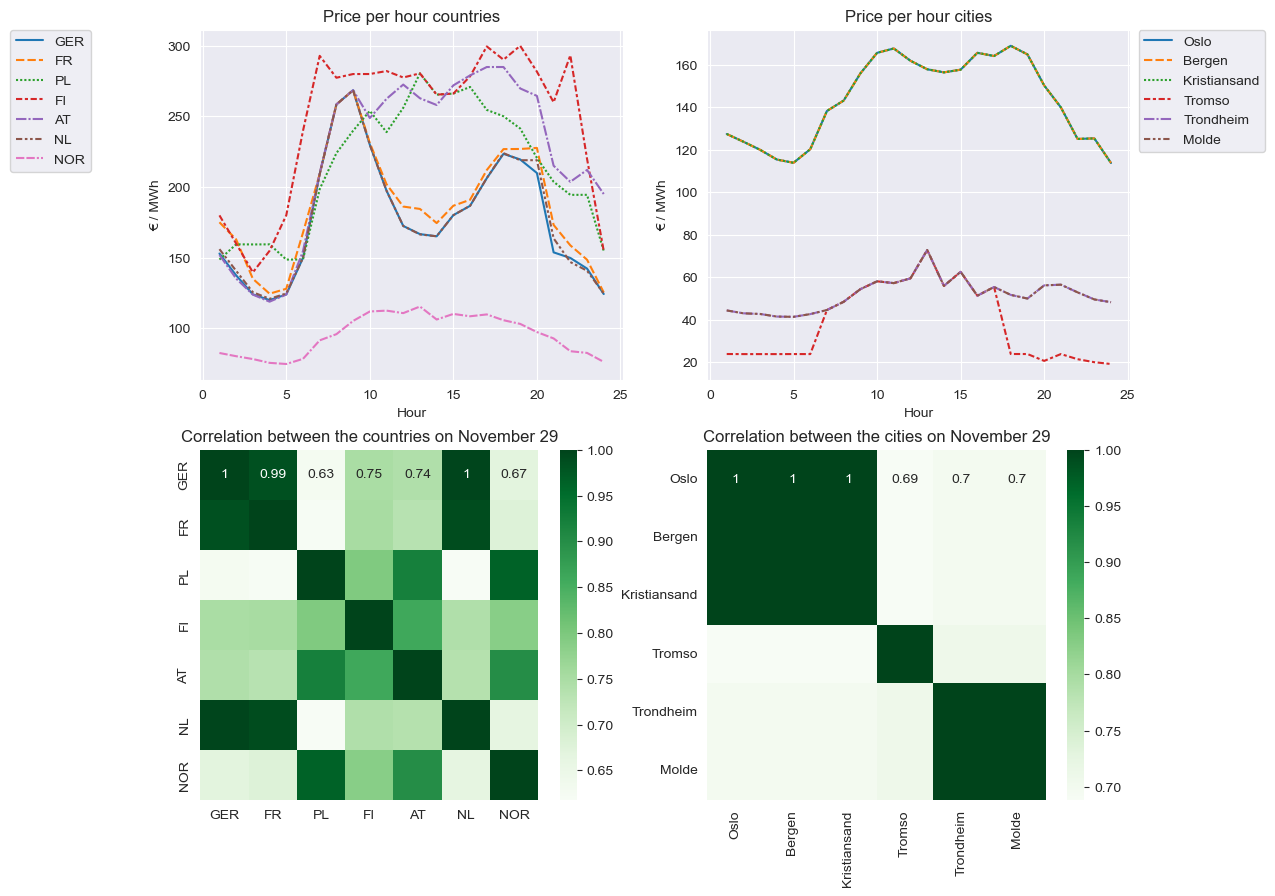

In [31]:
# lineplot countries
avg_prices_by_hour_countries = df_prices_november_countries.groupby('Hour').mean()
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12,10))
sns.lineplot(avg_prices_by_hour_countries, ax=axes[0,0])
axes[0,0].set_title('Price per hour countries')
axes[0,0].set_ylabel('€ / MWh')
axes[0,0].legend(bbox_to_anchor=(-0.45, 1), loc='upper left', borderaxespad=0)

# lineplot cities
avg_prices_by_hour_cities = df_prices_november_cities.groupby('Hour').mean()
sns.lineplot(avg_prices_by_hour_cities, ax=axes[0,1])
axes[0,1].set_title('Price per hour cities')
axes[0,1].set_ylabel('€ / MWh')
axes[0,1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

# correlation countries
corr_countries_nov = avg_prices_by_hour_countries.corr()
sns.heatmap(corr_countries_nov, annot=True, cmap='Greens', ax=axes[1,0])
axes[1,0].set_title('Correlation between the countries on November 29')

# correlation cities
corr_cities_nov = avg_prices_by_hour_cities.corr()
sns.heatmap(corr_cities_nov, annot=True, cmap='Greens', ax=axes[1,1])
axes[1,1].set_title('Correlation between the cities on November 29')

print('Graphic 3:')
plt.show()

In [32]:
# An overview of prices by countries
avg_prices_by_hour_countries.corr()

,GER,FR,PL,FI,AT,NL,NOR
GER,1.000000,0.985467,0.627812,0.749539,0.741889,0.997748,0.669199
FR,0.985467,1.000000,0.621975,0.753397,0.732732,0.989733,0.678100
PL,0.627812,0.621975,1.000000,0.796054,0.922300,0.617748,0.964494
FI,0.749539,0.753397,0.796054,1.000000,0.860000,0.742577,0.786829
AT,0.741889,0.732732,0.922300,0.860000,1.000000,0.736401,0.900973
NL,0.997748,0.989733,0.617748,0.742577,0.736401,1.000000,0.663319
NOR,0.669199,0.678100,0.964494,0.786829,0.900973,0.663319,1.000000


#### Perform analysis and visualization to compare the price changes between different countries in EU and different cities in Norway.

#### Price change in the EU countries

##### Graphic 1, shows a heatmap displaying the correlation between prices in the countries for the whole month. Here we see that most of the countries have a high correlation with each other meaning that they are close to 1.0 with some exceptions concerning Finland. It has a lower correlation to Germany (0.55), France (0.42), Austria (0.54) and Netherlands (0.51). The correlation between Finland and France is actually the lowest in the heat-map. On the opposite side of the scale, you  have Poland and Norway with the highest correlation at 0.98.

##### Graphic 2 on the left side, there is a scatterplot and a barplot showing prices for the different countries. France overall has the highest average price during October, followed closely by Austria. Norway actually has the cheapest average compared to the other nations in the barplot. This is also supported by the scatterplot showing that Norway is at the bottom from week 1 to 5 except during week 2.

##### Lastly graphic 3, shows price per hour for the different countries on a specific date, in this scenario November 29. Most of the countries do follow each other with some differences but the outlier this day is Norway at the bottom. The spikes are much higher at different hours for the other countries compared to Norway. While Finland has the highest price per hour of all the countries in the lineplot.

#### Price change in Norwegian cities

##### Looking at graphic 1, and the correlation between the Norwegian cities, there are groupings of cities with a perfect positive correlation. Meaning that the prices in these cities will raise and fall exactly the same time during the month of October. Oslo, Bergen and Kristiansand is one grouping while Molde and Trondheim is another grouping where the correlation is at 1. 

##### These results are supported by Graphic 2, showing mean prices in the different cities. Tromsø is actually the only city that isn't in a specific grouping and deviates from the rest. The scatterplot for the cities also shows the cities in the same grouping are overlapping each other week by week and therefore there isn't many different symbols if you compare it to the left scatterplot showing countries were there are a lot more symbols visible.

##### The same information is confirmed through graphic 3, Oslo, Bergen and Kristiansand has the highest price average compared to the other Norwegian cities, while Tromsø has the lowest price average for electricity. The heatmap in graphic 3 aswell shows the different groupings and those in the same group has a perfect positive correlation.